#Koduppgift 2

### Uppgift 9

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

a) Läs in datasetet “data_01.csv” med funktionen read_csv() från Pandas. Funktionen returnerar en DataFrame

In [3]:
df = pd.read_csv('./dataset/data_01.csv')

In [4]:
df.head(5)

,x1,x2,x3,x4,x5,target
0,0.743487,1.072825,1.332911,-1.244771,0.344978,220.173943
1,0.835264,0.202184,0.966480,0.745883,-0.033773,175.873929
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224,-162.270054
3,1.210186,1.685258,-0.394123,0.719024,-2.166585,165.930461
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473,43.250511


b) Dela upp datasetet i X och y.

In [5]:
X = df.drop('target', axis=1)
y = df['target']

In [6]:
X.head()

,x1,x2,x3,x4,x5
0,0.743487,1.072825,1.332911,-1.244771,0.344978
1,0.835264,0.202184,0.966480,0.745883,-0.033773
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224
3,1.210186,1.685258,-0.394123,0.719024,-2.166585
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473


In [7]:
y.head()

0    220.173943
1    175.873929
2   -162.270054
3    165.930461
4     43.250511
Name: target, dtype: float64

c) Dela upp datan ytterligare, i ett träning-, ett validering-, och ett testset med train_test_split(). Låt 20% av datan vara testdata och 15% av den återstående datan vara valideringsdata.

In [8]:
X_train_val, x_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=40)

d) Träna två valfria regressionsmodeller (exempelvis LinearRegression och DecisionTreeRegressor) på träningsdatan. Notera, i kapitel 3 kommer vi lära oss mer om DecisionTreeRegressor.

**Linear Regression Model**

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_val)

**Decision Tree Regression**

In [10]:
dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)
dt_pred = dt_reg.predict(X_val)

Jag känner att jag inte ville köra en gridsearch på den här för att det är i kapitel 3 i boken. och det kändes tråkigt att bara skriva av kod exemplet.

e) Utvärdera modellerna på valideringsdatan

In [11]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

validation_results = pd.DataFrame({
    'Linear Regression': regression_metrics(y_val, lin_reg_pred),
    'Decision Tree': regression_metrics(y_val, dt_pred)
}).T

validation_results

,MAE,RMSE
Linear Regression,2.603697,3.379782
Decision Tree,73.729955,92.348661


f) Träna om den bäst presterande modellen på både tränings- och valideringsdatan.

In [12]:
lin_reg_full = LinearRegression().fit(X_train_val, y_train_val)
pred_test = lin_reg_full.predict(x_test)

g) Utvärdera modellen på testdatan.

In [13]:
test_result = pd.Series(
    regression_metrics(y_test, pred_test),
    name='Test set'
)
test_result

MAE     2.685240
RMSE    3.371549
Name: Test set, dtype: float64

h) Träna om modellen på hela datasetet

In [14]:
lin_reg_all = LinearRegression().fit(X, y)

In [17]:
pred_test2 = lin_reg_all.predict(x_test)

In [18]:
test_result2 = pd.Series(
    regression_metrics(y_test, pred_test2),
    name='Test set'
)
test_result2

MAE     2.656167
RMSE    3.320253
Name: Test set, dtype: float64

### Uppgift 10

a) Läs in datasetet “salary_dataset.csv” med pandas read_csv()-funktion och dela upp i X och y. Avgör själv vilken variabel som ska vara den beroende variabeln y

In [21]:
df_sal = pd.read_csv('./dataset/salary_dataset.csv') #laddar in dataset
df_sal.head(5) #sanity check för att kolla att det gick

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [22]:
df_sal.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


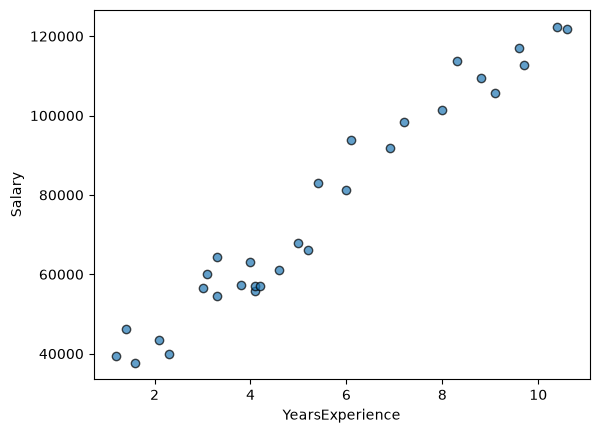

In [23]:
plt.scatter(df_sal['YearsExperience'], df_sal['Salary'], alpha=0.7, edgecolor='k')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

In [24]:
X = df_sal.drop('YearsExperience', axis=1)
y = df_sal['YearsExperience']

In [25]:
X.head()

,Salary
0,39344.0
1,46206.0
2,37732.0
3,43526.0
4,39892.0


In [26]:
y.head()

0    1.2
1    1.4
2    1.6
3    2.1
4    2.3
Name: YearsExperience, dtype: float64

b) Dela upp datasetet i träning- och testset. (Inget validerings-set alltså!)

In [27]:
X_full, X_val, y_full, y_val = train_test_split(X, y, test_size=0.2, random_state=34)

c) Träna två regressionsmodeller med k-delad korsvalidering med cross_validate()-funktionen från scikit-learn. Använd neg_root_mean_squared_error som scoring. Välj själv hur många iterationer den ska göra genom hyperparametern cv.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_validate

In [38]:
model1 = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])

model2 = RandomForestRegressor(n_estimators=100, random_state=42)

cv_results_1 = cross_validate(
    model1,
    X_full,
    y_full,
    cv=3,
    scoring="neg_root_mean_squared_error",
    return_train_score=False,
)

cv_results_2 = cross_validate(
    model2,
    X_full,
    y_full,
    cv=3,
    scoring="neg_root_mean_squared_error",
    return_train_score=False,
)

d) Utvärdera modellen som presterar bäst på testsetet.

In [39]:
print("--- Modell 1: Ridge Regression ---")
rmse_1 = -cv_results_1["test_score"]
print(f"RMSE per fold: {np.round(rmse_1, 2)}")
print(f"Medel-RMSE: {np.round(np.mean(rmse_1), 2)} (± {np.round(np.std(rmse_1), 2)})")

print("\n--- Modell 2: Random Forest ---")
rmse_2 = -cv_results_2["test_score"]
print(f"RMSE per fold: {np.round(rmse_2, 2)}")
print(f"Medel-RMSE: {np.round(np.mean(rmse_2), 2)} (± {np.round(np.std(rmse_2), 2)})")

--- Modell 1: Ridge Regression ---
RMSE per fold: [0.59 0.64 0.54]
Medel-RMSE: 0.59 (± 0.04)

--- Modell 2: Random Forest ---
RMSE per fold: [0.84 0.74 0.53]
Medel-RMSE: 0.7 (± 0.13)


### Uppgift 11

a) Läs in datasetet mpg med seaborns load_dataset()-funktion (det gjordes i koden ovan)

In [41]:
import seaborn as sns


df_s = sns.load_dataset("mpg")

In [42]:
df_s.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


horsepower är den som inte har komplett data

b) Droppa rader med saknade värden med dropna()-metoden.

In [43]:
df_s = df_s.dropna()

df_s.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    str    
 8   name          392 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 30.6 KB


c) Droppa kolumnen name

In [46]:
df_s = df_s.drop('name', axis=1)

df_s.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    str    
dtypes: float64(4), int64(3), str(1)
memory usage: 27.6 KB


d) Utför en dummy-variable-encoding på origin-kolumnen med pandas get_dummies()-funktion. Ange drop_first=True så att vi får 2 nya kolumner istället för 3

In [47]:
df_dummy = pd.get_dummies(df_s, columns=['origin'], drop_first=True, dtype= int)

df_dummy.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin_japan  392 non-null    int64  
 8   origin_usa    392 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 30.6 KB


e) Dela upp datasetet i X och y, med mpg som den beroende variabeln y

In [50]:
X = df_dummy.drop('mpg', axis=1)
y = df_dummy['mpg']

In [49]:
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,8,307.0,130.0,3504,12.0,70,0,1
1,8,350.0,165.0,3693,11.5,70,0,1
2,8,318.0,150.0,3436,11.0,70,0,1
3,8,304.0,150.0,3433,12.0,70,0,1
4,8,302.0,140.0,3449,10.5,70,0,1


In [51]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

f) Dela upp datasetet i träning- och testset

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=38)

g) Träna en linjär regressionsmodell på träningsdatan och utvärdera den på testdatan

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, lin_reg_pred)
rmse = np.sqrt(mse)

print(f"Test RMSE: {rmse:.4f}")